# 1. Importación

Carga de las librerías necesarias y del dataset resultante de `01D_eda_listings_full.ipynb`, ya limpio (`data/processed/listings_full_clean.csv`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_full_clean.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_license
0,18674,https://www.airbnb.com/rooms/18674,20260624162917,2026-06-25,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,https://a0.muscache.com/pictures/hosting/Hosti...,71615,https://www.airbnb.com/users/show/71615,...,4.64,4.83,4.38,Spain - National registration number<br />ESFC...,20,20,0,0,0.37,True
1,23197,https://www.airbnb.com/rooms/23197,20260624162917,2026-06-25,city scrape,CCIB Forum· Large Balcony · 5 min walk to CCIB,"Beautiful, spacious apartment with large balco...",https://a0.muscache.com/pictures/hosting/Hosti...,90417,https://www.airbnb.com/users/show/90417,...,4.99,4.69,4.71,Spain - National registration number<br />ESFC...,1,1,0,0,0.53,True
2,34981,https://www.airbnb.com/rooms/34981,20260624162917,2026-06-25,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,https://a0.muscache.com/pictures/c4d1723c-e479...,73163,https://www.airbnb.com/users/show/73163,...,4.75,4.65,4.48,Spain - National registration number<br />ESFC...,2,2,0,0,1.59,True
3,36763,https://www.airbnb.com/rooms/36763,20260624162917,2026-07-03,previous scrape,In front of the beach,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,158596,https://www.airbnb.com/users/show/158596,...,4.92,4.92,4.82,Sin licencia,1,0,1,0,0.60,False
4,40983,https://www.airbnb.com/rooms/40983,20260624162917,2026-06-25,city scrape,Architect's Loft near Gaudí & Passeig de Gràcia,Stay in a charming architect-designed loft in ...,https://a0.muscache.com/pictures/miso/Hosting-...,177617,https://www.airbnb.com/users/show/177617,...,4.86,4.91,4.52,Barcelona - Regional registration number<br />...,5,2,3,0,2.46,True


## 2. Selección de variables de partida

De las 78 columnas del dataset limpio, decidir cuáles se descartan antes de construir features (identificadores, URLs, texto libre sin procesar, columnas redundantes dentro de una misma familia) y cuáles se mantienen como base.

Se descartan seis grupos de columnas antes de construir ninguna feature:

1. **URLs y metadatos de scraping**: `listing_url`, `picture_url`, `host_url`, `host_profile_url`, `host_picture_url`, `scrape_id`, `last_scraped`, `source`, `calendar_last_scraped`. No describen el alojamiento.
2. **Texto libre sin procesar**: `name`, `description`, `host_about`, `amenities`, `host_location`. Se decide de forma definitiva no explotar señal de texto en `name`/`description`/`host_about`/`host_location` (razonamiento justo debajo). `amenities` es distinto: no se descarta, se trata aparte en una fase posterior de este mismo proyecto (flags derivados por palabra clave — aire acondicionado, piscina, lavavajillas, nº total de amenities — no como texto libre sin más). Por ahora, para esta pasada de limpieza, se excluye igual que el resto del grupo y se retoma cuando toque esa fase.
3. **Columnas que ya cumplieron su función**: `bathrooms_text` (ya se extrajo `bathrooms` numérico), `license` (ya existe `has_license`), `host_name` (identificador, no aporta como categórica) y `host_listings_count` (redundante con `calculated_host_listings_count`, que es más fiable porque se recalcula sobre el propio dataset).
4. **`price_quote_*`**: se comprueba a continuación por qué se descartan.
5. **Familias redundantes** detectadas en la EDA: las variantes de `minimum_nights`/`maximum_nights` (quedándonos solo con la base), las de `availability` (quedándonos solo con `availability_365`) y las ventanas de reviews más finas (`number_of_reviews_l30d`, `number_of_reviews_ly`).
6. **`estimated_revenue_l365d`**: riesgo de fuga de información, se comprueba también a continuación.

#### ¿Por qué se descarta `price_quote_*`?

Quedó pendiente desde la EDA. Al mirar los valores de cerca, `price_quote_price_per_night` coincide exactamente con `price` en todas las filas, y `price_quote_raw` es el JSON de una cotización pedida para unas fechas concretas de check-in y check-out, construida a partir del propio `price` (con algún descuento por estancia larga aplicado encima). No es información nueva, es el mismo dato reempaquetado.

In [3]:
(df["price"] == df["price_quote_price_per_night"]).mean()

np.float64(1.0)

#### ¿Por qué se descarta `estimated_revenue_l365d`?

Porque se calcula multiplicando `price` por `estimated_occupancy_l365d`. Usarla como feature para predecir `price` sería fuga de información: el modelo vería una variable que ya contiene la respuesta.

#### ¿Por qué se descartan `name`, `description`, `host_about` y `host_location`?

Son texto libre sin estructura, y sacarles señal de verdad requeriría NLP (palabras clave, sentimiento, embeddings) para un beneficio incierto: `name`/`description` son copy de marketing escrito por el host, no una descripción objetiva del alojamiento, y la parte que sí sería objetiva (tamaño, ubicación, equipamiento) ya está capturada en columnas estructuradas del propio dataset. `host_about`/`host_location` son metadatos de perfil del host, redundantes con las señales de host que ya existen (`host_is_superhost`, antigüedad, tamaño de portfolio) sin aportar nada claramente nuevo. A diferencia de `amenities` (ver arriba), aquí no queda ningún hilo suelto: se descartan de forma definitiva, no como algo pendiente de revisar más adelante.

In [4]:
(df["price"] * df["estimated_occupancy_l365d"]).corr(df["estimated_revenue_l365d"])

np.float64(0.9999999999834529)

#### Aplicando los descartes

In [5]:
drop_cols = [
    # URLs y metadatos de scraping
    "listing_url", "picture_url", "host_url", "host_profile_url", "host_picture_url",
    "scrape_id", "last_scraped", "source", "calendar_last_scraped",
    # texto libre sin procesar (amenities NO va aquí: se procesa en la sección 9)
    "name", "description", "host_about", "host_location",
    # columnas que ya cumplieron su función
    "bathrooms_text", "license", "host_name", "host_listings_count",
    # price_quote_* (redundante con price)
    "price_quote_checkin_date", "price_quote_checkout_date", "price_quote_total_price",
    "price_quote_price_per_night", "price_quote_raw",
    # familias redundantes de estancia
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    # familia redundante de disponibilidad
    "availability_30", "availability_60", "availability_90", "availability_eoy",
    # ventanas de reviews más finas
    "number_of_reviews_l30d", "number_of_reviews_ly",
    # fuga de información
    "estimated_revenue_l365d",
]

df = df.drop(columns=drop_cols)
df.shape

(13258, 43)

Quedan 43 columnas de partida. `id`, `host_id` y `host_profile_id` se mantienen como identificadores de referencia, no como features del modelo. `amenities` se deja para la sección 9, después de las transformaciones numéricas/categóricas/host/reviews/geografía habituales, porque necesita su propio tratamiento (parsear la lista y construir flags por palabra clave). El resto son las que se van a transformar en las siguientes secciones: variables de tamaño y calidad, categóricas, señales de host, reviews y geografía.

In [6]:
df.columns.tolist()

['id',
 'host_id',
 'host_profile_id',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'has_lice

## 3. Transformaciones numéricas

Logaritmos y ratios sobre las variables numéricas con distribución muy asimétrica (`price`, variables de reviews) y sobre las nuevas variables de tamaño (`accommodates`, `bedrooms`, `beds`, `bathrooms`).

### 3.1 Logaritmos

En la EDA se midió la asimetría de cada variable numérica. Se aplica `log1p` (en vez de `log` normal, porque admite ceros) a las que tienen un coeficiente de asimetría alto: `price` (9.0), `reviews_per_month` (13.7), `number_of_reviews` (4.1), `number_of_reviews_ltm`, `bedrooms` (4.6), `beds` (4.1), `bathrooms` (4.0) y `calculated_host_listings_count` (2.2). Se guardan como columnas nuevas con sufijo `_log`, sin sustituir a las originales, así el modelo puede usar la que mejor le venga.

In [7]:
log_vars = [
    "price", "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "bedrooms", "beds", "bathrooms", "calculated_host_listings_count",
]

for c in log_vars:
    df[f"{c}_log"] = np.log1p(df[c])

Se comprueba el efecto sobre `price`, la más asimétrica de todas.

Text(0.5, 1.0, 'price_log')

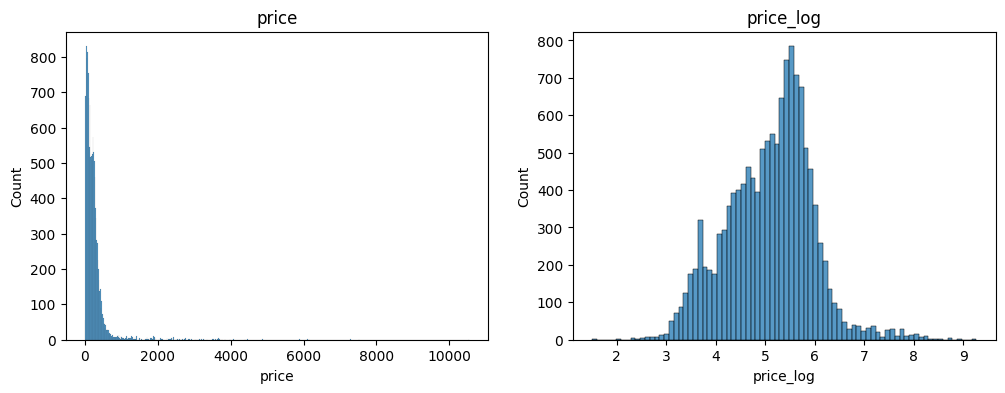

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df, x="price", ax=axes[0])
axes[0].set_title("price")
sns.histplot(df, x="price_log", ax=axes[1])
axes[1].set_title("price_log")

La distribución pasa de una cola muy larga a una forma mucho más cercana a la normal. Esto es lo que se busca para un modelo lineal; para un modelo basado en árboles no hace tanta falta, pero no hace daño tenerlo disponible.

### 3.2 Ratios

`price_per_accommodate` normaliza el precio por la capacidad del alojamiento: dos anuncios con precios muy distintos pueden estar igual de bien o mal valorados si uno acoge al doble de gente. Se usa `accommodates` como denominador porque nunca vale 0 (mínimo 1); `bedrooms` y `bathrooms` sí tienen algún 0, así que no son denominadores seguros sin más cuidado. `price_per_min_night` reaparece de `02A_fe_listings.ipynb`, ahora sobre este dataset.

In [9]:
df["price_per_accommodate"] = df["price"] / df["accommodates"]
df["price_per_min_night"] = df["price"] / df["minimum_nights"]

df[["price_per_accommodate", "price_per_min_night"]].describe()

,price_per_accommodate,price_per_min_night
count,13258.000000,13258.000000
mean,60.517062,163.210348
std,66.669871,329.095863
min,2.462222,0.014000
25%,34.436250,3.237661
50%,51.206875,91.292500
75%,74.000000,217.000000
max,5271.110000,7532.000000


<Axes: xlabel='price_per_accommodate', ylabel='Count'>

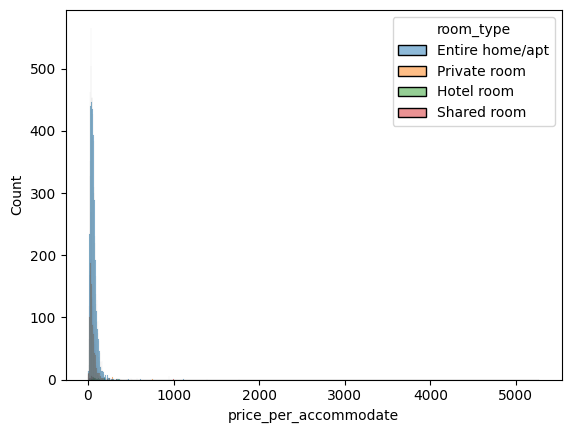

In [10]:
sns.histplot(df, x="price_per_accommodate", hue="room_type")

## 4. Variables de tamaño: multicolinealidad

`accommodates`, `bedrooms`, `beds` y `bathrooms` están muy correlacionadas entre sí. Decidir si se mantienen todas, se combinan en un índice, o se descarta alguna.

La correlación entre `accommodates`/`bedrooms`/`beds`/`bathrooms` (0.80-0.84 en la EDA) es alta a simple vista, pero eso no dice por sí solo si es un problema real para un modelo. La medida estándar es el VIF (Variance Inflation Factor): compara cuánto se puede predecir cada variable a partir de las otras tres. Un VIF de 1 significa que no hay redundancia; a partir de 5, y sobre todo de 10, se considera multicolinealidad seria.

In [11]:
size_vars = ["accommodates", "bedrooms", "beds", "bathrooms"]

corr_matrix = df[size_vars].corr().values
vif = np.diag(np.linalg.inv(corr_matrix))

pd.Series(vif, index=size_vars, name="VIF")

accommodates    3.883279
bedrooms        4.312083
beds            4.236392
bathrooms       1.834302
Name: VIF, dtype: float64

Los cuatro VIF están entre 1.8 y 4.3, por debajo del umbral de 5. La correlación es alta, pero no lo bastante como para que cada variable sea redundante con el resto: cada una sigue aportando información propia (`bathrooms` es la que menos se solapa con las otras tres, con VIF 1.83). Se mantienen las cuatro tal cual, sin combinarlas en un índice ni descartar ninguna.

Esto solo importaría de verdad para un modelo lineal, donde una multicolinealidad alta infla la varianza de los coeficientes y los hace inestables. Para un modelo basado en árboles no tiene ningún efecto. Si más adelante se prueba una regresión lineal y los coeficientes de estas variables salen con signos raros o muy inestables entre distintos folds, este es el sitio al que volver.

## 5. Codificación de categóricas

`room_type`, `neighbourhood_group_cleansed`, `neighbourhood_cleansed` y `property_type`: agrupar categorías raras donde haga falta y codificar (one-hot, ordinal o target encoding según el caso).

Las cuatro variables categóricas necesitan tratamientos distintos según su cardinalidad: `room_type` y `neighbourhood_group_cleansed` son pocas categorías y se codifican directamente; `neighbourhood_cleansed` y `property_type` tienen demasiadas para un one-hot directo, así que cada una se resuelve a su manera.

### 5.1 `room_type`

4 categorías sin orden natural: one-hot encoding.

In [12]:
df = pd.get_dummies(df, columns=["room_type"], prefix="room_type")

### 5.2 `neighbourhood_group_cleansed`

10 categorías sin orden natural: mismo tratamiento.

In [13]:
df = pd.get_dummies(df, columns=["neighbourhood_group_cleansed"], prefix="district")

### 5.3 `neighbourhood_cleansed`

69 categorías: un one-hot directo generaría 69 columnas casi todas dispersas. En vez de agrupar las raras en "Otros" como en la EDA, aquí se usa **target encoding suavizado**: cada barrio se sustituye por su precio medio, mezclado con el precio medio global cuando el barrio tiene pocos anuncios, para que un barrio con 3 anuncios no quede con una media ruidosa basada solo en esos 3 valores.

**Aviso importante**: esta media se calcula aquí con todo el dataset, solo para tener la columna disponible y poder seguir explorando en el resto de este notebook — no es la versión final. Antes de entrenar un modelo de verdad hay que recalcularla usando únicamente los datos de entrenamiento, o se estaría filtrando información del conjunto de test al de entrenamiento. Por eso `neighbourhood_cleansed` (la columna cruda) se mantiene más allá de la limpieza final de la sección 9, en vez de descartarse aquí mismo: la corrección real ocurre en `03_model_baseline.ipynb`, justo después del split, que es el primer punto de todo el pipeline donde train y test están separados y tiene sentido recalcular algo "solo con train".

In [14]:
global_mean_price = df["price"].mean()
neigh_stats = df.groupby("neighbourhood_cleansed")["price"].agg(["mean", "count"])

smoothing = 10
smoothed_mean = (neigh_stats["count"] * neigh_stats["mean"] + smoothing * global_mean_price) / (neigh_stats["count"] + smoothing)

df["neighbourhood_price_encoded"] = df["neighbourhood_cleansed"].map(smoothed_mean)

In [15]:
df[["neighbourhood_cleansed", "neighbourhood_price_encoded"]].drop_duplicates().sort_values("neighbourhood_price_encoded", ascending=False).head(10)

,neighbourhood_cleansed,neighbourhood_price_encoded
25,Diagonal Mar i el Front Marítim del Poblenou,379.419041
4,la Dreta de l'Eixample,353.494684
38,la Nova Esquerra de l'Eixample,328.391228
16,Sant Antoni,312.324277
101,la Vila Olímpica del Poblenou,281.889275
243,Hostafrancs,280.960022
0,la Sagrada Família,266.841810
443,la Marina del Prat Vermell,255.977198
29,el Fort Pienc,250.779512
24,l'Antiga Esquerra de l'Eixample,249.561175


### 5.4 `property_type`

47 categorías, pero muy concentradas: `Entire rental unit` y `Private room in rental unit` son el 85% del dataset, y 34 de las 47 categorías tienen menos de 30 anuncios. Aquí sí interesa agrupar en "Otros" antes de codificar (a diferencia de `neighbourhood_cleansed`, que tiene mucha más variación geográfica útil que conviene conservar con target encoding): tras agrupar quedan 14 categorías, un one-hot manejable y más interpretable que una columna de media de precio.

In [16]:
property_type_counts = df["property_type"].value_counts()
rare_property_types = property_type_counts[property_type_counts < 30].index

df["property_type_grouped"] = df["property_type"].where(
    ~df["property_type"].isin(rare_property_types), "Other"
)
df["property_type_grouped"].nunique()

14

In [17]:
df = pd.get_dummies(df, columns=["property_type_grouped"], prefix="property_type")

Con esto, `room_type`, `neighbourhood_group_cleansed` y `property_type_grouped` quedan como columnas binarias, y `neighbourhood_cleansed` como una única columna numérica (`neighbourhood_price_encoded`). `property_type` (texto) se descarta en la limpieza final de la sección 9, como estaba previsto. `neighbourhood_cleansed` (texto) es la excepción: se mantiene más allá de esa limpieza, hasta después del split en `03_model_baseline.ipynb`, donde se recalcula `neighbourhood_price_encoded` solo con train (ver aviso de 5.3) — y ahí sí se descarta, una vez cumplida su función.

## 6. Variables derivadas del host

Señales sobre el tipo de host a partir de `calculated_host_listings_count`, `host_is_superhost` y la antigüedad (`hosts_time_as_host_years`).

### 6.1 Antigüedad del host

`hosts_time_as_host_years` y `hosts_time_as_host_months` guardan la antigüedad partida en dos columnas (años y el resto en meses). Se combinan en una sola variable continua.

In [18]:
df["host_tenure_years"] = df["hosts_time_as_host_years"] + df["hosts_time_as_host_months"] / 12
df["host_tenure_years"].describe()

count    13258.000000
mean         8.284130
std          4.424189
min          0.000000
25%          4.250000
50%          8.416667
75%         12.166667
max         15.500000
Name: host_tenure_years, dtype: float64

### 6.2 Tamaño del host

Antes de convertir `calculated_host_listings_count` en un flag binario tipo "profesional o no", se comprueba qué umbral tendría sentido.

In [19]:
for threshold in [1, 2, 5, 10]:
    pct = (df["calculated_host_listings_count"] > threshold).mean() * 100
    print(f"más de {threshold} anuncios: {pct:.1f}%")

más de 1 anuncios: 84.6%
más de 2 anuncios: 77.2%
más de 5 anuncios: 64.4%
más de 10 anuncios: 52.4%


Un flag binario no sirve aquí: con `> 1` ya se marca al 84.6% de los anuncios como "profesional", porque la mediana de `calculated_host_listings_count` es 12. Este mercado está dominado por hosts con muchos anuncios, no es la excepción. En vez de un umbral arbitrario, se construyen 4 categorías (los cuartiles ya calculados en la EDA: 1, 3, 12, 51): `individual` (1 anuncio), `pequeno` (2-10), `mediano` (11-50) y `grande` (51+).

In [20]:
bins = [0, 1, 10, 50, df["calculated_host_listings_count"].max()]
labels = ["individual", "pequeno", "mediano", "grande"]
df["host_size_tier"] = pd.cut(df["calculated_host_listings_count"], bins=bins, labels=labels)

df.groupby("host_size_tier", observed=True)["price"].agg(["count", "median"])

,count,median
host_size_tier,,
individual,2036,149.185
pequeno,4277,177.000
mediano,3549,201.000
grande,3396,173.000


La relación no es monótona (`mediano` es el que más cobra de mediana, no `grande`), así que un valor ordinal (1, 2, 3, 4) podría confundir a un modelo lineal al asumir un orden que no se cumple en el efecto. Se codifica con one-hot en vez de como número ordinal.

In [21]:
df = pd.get_dummies(df, columns=["host_size_tier"], prefix="host_size")

### 6.3 Composición del portfolio del host

`calculated_host_listings_count_entire_homes` frente al total del host: qué proporción de los anuncios de ese host son pisos enteros, en vez de habitaciones. Puede distinguir gestoras especializadas en alquiler completo de hosts con un modelo más mixto.

In [22]:
df["host_entire_homes_ratio"] = (
    df["calculated_host_listings_count_entire_homes"] / df["calculated_host_listings_count"]
)
df["host_entire_homes_ratio"].corr(df["price"])

np.float64(0.23384664196032728)

0.23 de correlación con `price`, algo mejor que la del propio `calculated_host_listings_count` (0.21). No es una señal fuerte por sí sola, pero aporta un matiz distinto: no es solo cuántos anuncios tiene el host, sino de qué tipo.

## 7. Variables derivadas de reviews

Señales a partir de `review_scores_rating` y compañía, teniendo en cuenta que una parte de los anuncios no tiene reviews todavía.

### 7.1 `has_reviews`

El 22% de los anuncios no tiene reviews todavía, y por eso `review_scores_rating` es `NaN` en esas filas (no un dato perdido, un dato que no existe). Antes de tocar nada, se deja explícito con un flag: así un modelo puede distinguir "sin reviews" de cualquier imputación que se haga después.

In [23]:
df["has_reviews"] = df["number_of_reviews"] > 0
df["has_reviews"].value_counts()

has_reviews
True     10331
False     2927
Name: count, dtype: int64

### 7.2 Antigüedad y recencia de reviews

`first_review` y `last_review` como fechas no son directamente útiles para un modelo; interesa más el tiempo transcurrido. Se descartó `last_scraped` en la sección 2 (era metadato de scraping, no del alojamiento), así que como fecha de referencia se usa la `last_review` más reciente de todo el dataset, que hace de "hoy" aproximado.

In [24]:
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])

reference_date = df["last_review"].max()
df["listing_age_days"] = (reference_date - df["first_review"]).dt.days
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days

df[["listing_age_days", "days_since_last_review"]].describe()

,listing_age_days,days_since_last_review
count,10331.000000,10331.000000
mean,1673.248475,169.794792
std,1399.467838,390.560187
min,8.000000,0.000000
25%,510.000000,20.000000
50%,1264.000000,31.000000
75%,2661.000000,131.000000
max,5751.000000,5488.000000


Ambas quedan `NaN` para los anuncios sin reviews, coherente con `has_reviews`. La correlación con `price` es débil en las dos (0.13 en `listing_age_days`, -0.07 en `days_since_last_review`), pero es información que antes estaba encerrada en un texto de fecha y ahora el modelo puede usar directamente.

### 7.3 Los 6 subscores de review

`review_scores_accuracy`, `_cleanliness`, `_checkin`, `_communication`, `_location` y `_value` correlacionan entre 0.59 y 0.86 con `review_scores_rating`, y tienen exactamente los mismos nulos. Es la misma redundancia que ya se resolvió con las familias de `minimum_nights` y `availability` en la sección 2: se conserva `review_scores_rating` como resumen y se descartan los 6 subscores.

In [25]:
df = df.drop(columns=[
    "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location", "review_scores_value",
])

`review_scores_rating` se deja como `NaN` para los anuncios sin reviews, sin imputar: en la EDA ya se vio que apenas correlaciona con `price` (0.08), así que inventar un valor no aportaría nada y sí podría introducir ruido. Un modelo basado en árboles puede trabajar con esos `NaN` directamente; si se usa un modelo lineal, es el sitio al que volver.

## 8. Variables geográficas

Alguna codificación adicional de `latitude`/`longitude` más allá del barrio (p. ej. distancia al centro de la ciudad).

### 8.1 Distancia al centro

`neighbourhood_price_encoded` (sección 5) captura el efecto del barrio, pero es una variable discreta: dos anuncios muy cerca uno de otro pero a cada lado de la frontera de un barrio tendrían valores distintos sin motivo real. La distancia en línea recta al centro de la ciudad (Plaça Catalunya, referencia habitual) da una versión continua del mismo patrón espacial que ya se vio en el mapa de la EDA.

In [26]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

center_lat, center_lon = 41.3874, 2.1686  # Plaça Catalunya
df["distance_to_center_km"] = haversine(df["latitude"], df["longitude"], center_lat, center_lon)

df["distance_to_center_km"].describe()

count    13258.000000
mean         1.827570
std          1.137719
min          0.022265
25%          0.981277
50%          1.594452
75%          2.389423
max          8.360027
Name: distance_to_center_km, dtype: float64

Correlación débil con `price` (-0.11, -0.15 con `price_log`) y moderada con `neighbourhood_price_encoded` (-0.43): están relacionadas pero no son la misma información, cada una aporta algo distinto. `distance_to_center_km` se queda como complemento, no como sustituto del barrio.

In [27]:
df["distance_to_center_km"].corr(df["price"]), df["distance_to_center_km"].corr(df["neighbourhood_price_encoded"])

(np.float64(-0.1087677750564624), np.float64(-0.43181843718474267))

Text(0, 0.5, 'log1p(price)')

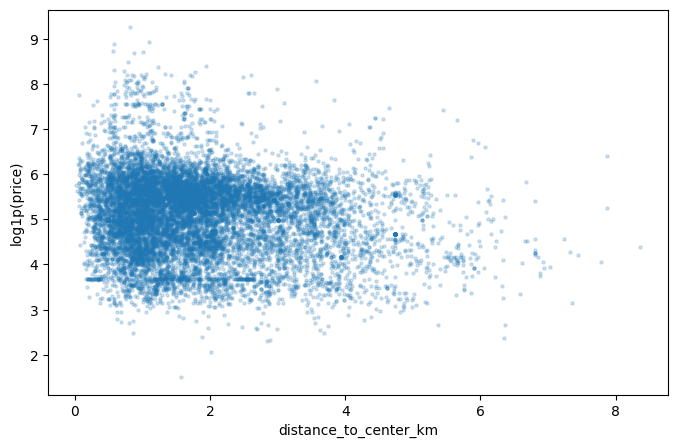

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(df["distance_to_center_km"], np.log1p(df["price"]), s=5, alpha=0.2)
plt.xlabel("distance_to_center_km")
plt.ylabel("log1p(price)")

Se ve la tendencia decreciente, pero con mucha dispersión: la distancia al centro por sí sola no basta para explicar el precio, es una señal más entre varias, coherente con el resto de la sección.

### 8.2 Densidad de anuncios cercanos

Motivado en la sección 11.5 de la EDA: cuántos otros anuncios reales hay en un radio de 150 metros de cada uno, con `BallTree` y distancia haversine. Complementa a `distance_to_center_km`: dos anuncios a la misma distancia del centro pueden estar en un tramo con mucha oferta alrededor o completamente aislados.

In [29]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
df["n_nearby_150m"] = counts - 1  # excluir el propio anuncio

df["n_nearby_150m"].describe()

count    13258.000000
mean        54.942374
std         36.239056
min          0.000000
25%         24.000000
50%         52.000000
75%         79.000000
max        165.000000
Name: n_nearby_150m, dtype: float64

Mismo resultado que en la EDA (media ~55, mediana 52, rango 0-165): correlación modesta con `price` (0.12), consistente con lo ya visto. Se mantiene como candidata, en la misma línea que `distance_to_center_km`.

## 9. Amenities

Se construyen las cuatro variables motivadas en la sección 12 de la EDA: `has_ac`, `has_pool` y `has_dishwasher` (flags por palabra clave, agrupando las distintas formas de escribir un mismo concepto — ver el ejemplo de "aire acondicionado" en 4 variantes distintas en la EDA) y `n_amenities` (recuento total, proxy barato de "anuncio bien equipado"). Un one-hot directo de las 2337 categorías de `amenities` no es viable (57% son variantes que aparecen una sola vez), así que no se intenta.

### 9.1 Parsear y construir los flags

In [30]:
import ast

amenities_parsed = df["amenities"].apply(ast.literal_eval)

def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

df["has_ac"] = amenities_parsed.apply(lambda l: has_any(l, ["air condition", "ac - "]))
df["has_pool"] = amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"]))
df["has_dishwasher"] = amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"]))
df["n_amenities"] = amenities_parsed.apply(len)

df[["has_ac", "has_pool", "has_dishwasher", "n_amenities"]].describe()

,n_amenities
count,13258.000000
mean,29.740987
std,13.117898
min,0.000000
25%,21.000000
50%,30.000000
75%,38.000000
max,84.000000


Prevalencias consistentes con la EDA (`has_ac` ~85%, `has_dishwasher` ~48%, `has_pool` ~4%, `n_amenities` media ~30). `has_pool` es rara, pero se mantiene igual que se decidió en la EDA: una correlación débil por baja prevalencia no es lo mismo que una variable sin sentido.

### 9.2 Descartar `amenities`

Ya cumplió su función (de ahí salen los 4 flags de arriba): se descarta el texto crudo, igual que se hizo con `property_type` en la sección 5.4 una vez codificado.

In [31]:
df = df.drop(columns=["amenities"])
df.shape

(13258, 88)

## 10. Dataset final para modelado

Selección de las columnas finales y guardado en `data/processed/` para los notebooks de modelado.

### 10.1 Un último cabo suelto: `hosts_time_as_user_*`

En la sección 6 se combinó la antigüedad como host (`hosts_time_as_host_years`/`_months`) en `host_tenure_years`, pero se quedó sin tocar la antigüedad como usuario de Airbnb en general (`hosts_time_as_user_years`/`_months`), que puede ser mayor si alguien fue huésped antes de publicar su primer anuncio. Se combina igual, por coherencia.

In [32]:
df["host_user_tenure_years"] = df["hosts_time_as_user_years"] + df["hosts_time_as_user_months"] / 12

### 10.2 Limpieza final

Se descartan las columnas que ya quedaron sustituidas por una versión mejor a lo largo del notebook: `property_type` en texto (ya está `property_type_*`), las cuatro columnas de antigüedad ya combinadas, `first_review`/`last_review` en formato fecha (ya están `listing_age_days` y `days_since_last_review`), y el desglose `calculated_host_listings_count_entire_homes`/`_private_rooms`/`_shared_rooms` (ya está resumido en `host_entire_homes_ratio`, y los tres suman siempre el total, así que son casi tan redundantes entre sí como las familias de la sección 2).

`neighbourhood_cleansed` (texto) es la excepción, no se descarta aquí: como se explicó en 5.3, se mantiene en el dataset exportado para que `03_model_baseline.ipynb` pueda recalcular `neighbourhood_price_encoded` solo con los datos de train justo después del split, y descartarla entonces.

In [33]:
final_drop = [
    "property_type",
    "hosts_time_as_host_years", "hosts_time_as_host_months",
    "hosts_time_as_user_years", "hosts_time_as_user_months",
    "first_review", "last_review",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

df = df.drop(columns=final_drop)
df.shape

(13258, 79)

### 10.3 Comprobación de nulos

Debería quedar solo lo que se dejó así a propósito: todo lo relacionado con anuncios sin reviews todavía.

In [34]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

review_scores_rating      2927
listing_age_days          2927
days_since_last_review    2927
dtype: int64

Los tres coinciden en las mismas 2927 filas (`has_reviews == False`), tal y como se esperaba. No hace falta ninguna acción más.

### 10.4 Identificadores, objetivo y features

Antes de guardar, queda explícito qué es cada cosa: `id`, `host_id` y `host_profile_id` son referencias, no entran como input del modelo; `price` es la variable objetivo; `neighbourhood_cleansed` viaja en el CSV pero todavía no es una feature (ver 5.3 y 10.2: es la columna cruda pendiente de la corrección de fuga en `03_model_baseline.ipynb`); el resto son las features.

In [35]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
pending_cols = ["neighbourhood_cleansed"]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + pending_cols]

print("identificadores:", len(id_cols))
print("objetivo:", target_col)
print("pendiente de la corrección de fuga (03_model_baseline.ipynb):", len(pending_cols))
print("features:", len(feature_cols))

identificadores: 3
objetivo: price
pendiente de la corrección de fuga (03_model_baseline.ipynb): 1
features: 74


### 10.5 Exportar

In [36]:
df.to_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_full_features.csv", index=False)